# Multicollinearity: Detection and Remedies

## Overview

Multicollinearity occurs when predictors are highly correlated. It does not bias coefficient estimates, but inflates their standard errors — making it difficult to determine which predictors are driving the response. Severe collinearity makes individual coefficients unreliable even when the model predicts well.

**Effects of collinearity:**
- Inflated standard errors → wide confidence intervals
- Unstable coefficients — small data changes produce large coefficient swings
- Individual predictors appear non-significant despite strong joint predictive power
- Coefficients may have unexpected signs

**Detection tools:**

| Tool | Threshold | Notes |
|---|---|---|
| Correlation matrix | \|r\| > 0.7 | Pairwise only; misses multivariate collinearity |
| VIF (Variance Inflation Factor) | VIF > 5 concerning; > 10 severe | Captures multivariate collinearity |
| Condition number | > 30 concerning | Eigenvalue-based; most sensitive |
| Tolerance | < 0.1 | Tolerance = 1/VIF |

**VIF formula:** $\text{VIF}_j = \frac{1}{1-R^2_j}$ where $R^2_j$ is the R² from regressing predictor $j$ on all other predictors.

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(car)           # vif()
library(corrplot)      # corrplot()
library(glmnet)        # ridge regression
library(patchwork)

set.seed(42)

n <- 200
# Create correlated predictors
nitrate     <- rnorm(n, 4, 1.5)
phosphorus  <- 0.85*nitrate + rnorm(n, 0, 0.4)      # r ≈ 0.90 with nitrate
ammonia     <- 0.70*nitrate + rnorm(n, 0, 0.6)      # r ≈ 0.75 with nitrate
conductivity<- 30*nitrate + rnorm(n, 100, 15)        # r ≈ 0.95 with nitrate
water_qual  <- 10 - 0.6*nitrate + rnorm(n, 0, 1)    # negatively correlated
elevation   <- rnorm(n, 200, 80)                     # independent

mc_data <- tibble(
  nitrate, phosphorus, ammonia, conductivity, water_qual, elevation,
  richness = 25 - 1.5*nitrate + 0.8*water_qual +
             0.01*elevation + rnorm(n, 0, 2)
)

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'car' was built under R version 4.4.3"
Loading required package: carData

Warning message:
"package 'carDat

---

## Detection

# A tibble: 6 × 3
  predictor      VIF severity  
  <chr>        <dbl> <chr>     
1 nitrate      23.3  Severe    
2 phosphorus   11.4  Severe    
3 ammonia       3.53 Acceptable
4 conductivity 10.6  Severe    
5 water_qual    1.6  Acceptable
6 elevation     1.01 Acceptable


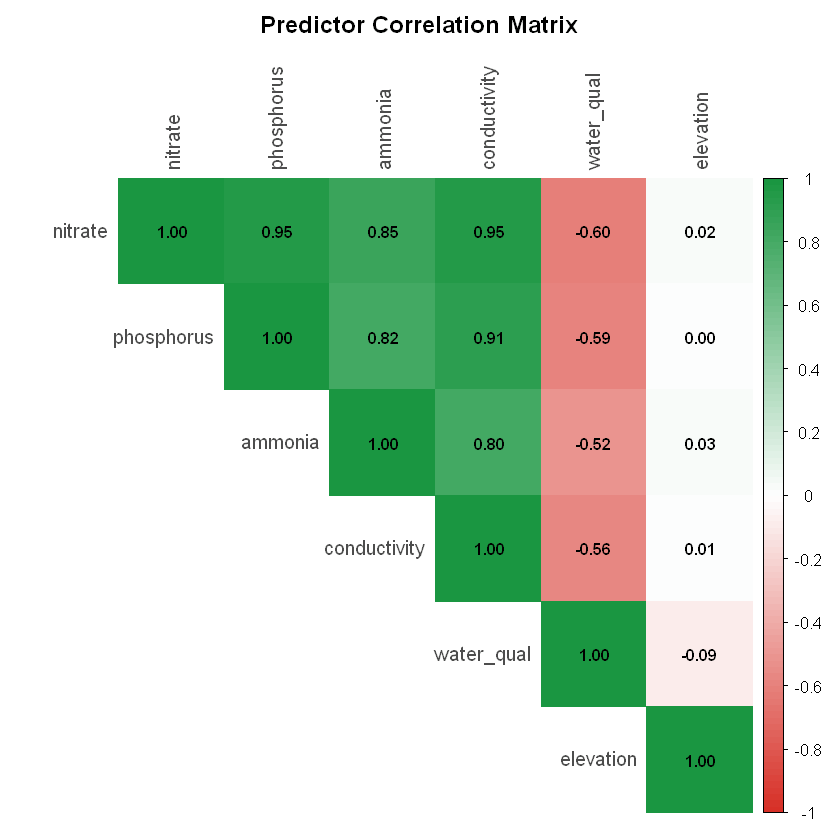

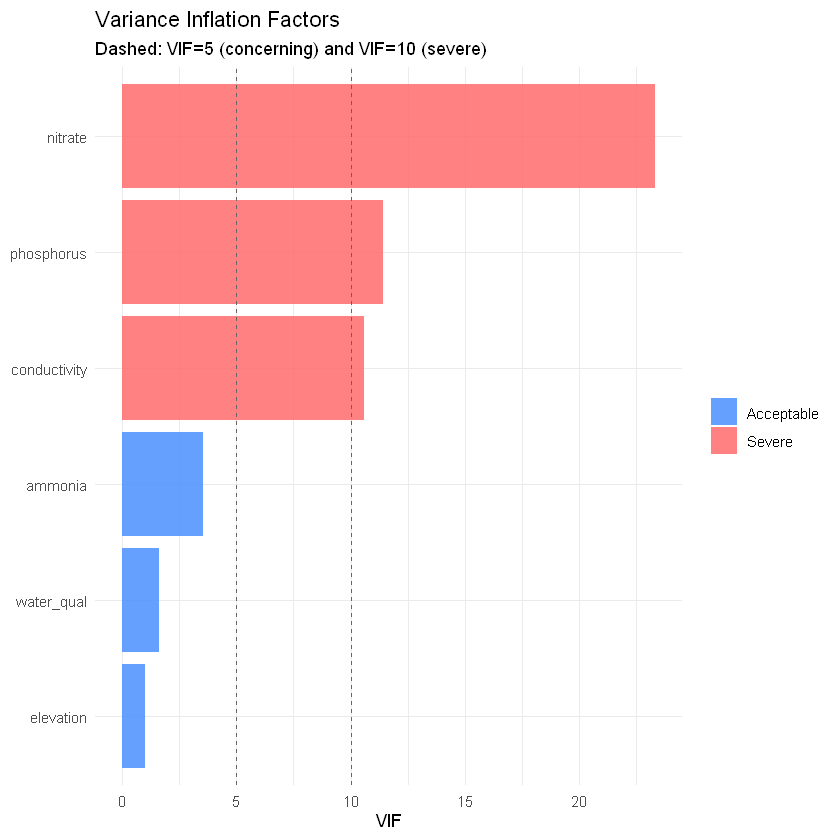

In [2]:
# ── Correlation matrix ────────────────────────────────────────────────────────
pred_cols <- c("nitrate","phosphorus","ammonia","conductivity","water_qual","elevation")
cor_mat   <- cor(mc_data[, pred_cols])

corrplot::corrplot(
  cor_mat,
  method   = "color",
  type     = "upper",
  addCoef.col = "black",
  number.cex  = 0.8,
  col      = colorRampPalette(c("#d73027","white","#1a9641"))(100),
  tl.col   = "gray30",
  title    = "Predictor Correlation Matrix",
  mar      = c(0,0,2,0)
)

# ── VIF ───────────────────────────────────────────────────────────────────────
# Fit model with all predictors
lm_full <- lm(richness ~ nitrate + phosphorus + ammonia +
                conductivity + water_qual + elevation,
              data=mc_data)

vif_vals <- car::vif(lm_full)
vif_df   <- tibble(
  predictor = names(vif_vals),
  VIF       = round(vif_vals, 2),
  severity  = case_when(
    VIF < 5  ~ "Acceptable",
    VIF < 10 ~ "Concerning",
    TRUE     ~ "Severe"
  )
)
print(vif_df)

ggplot(vif_df, aes(x=fct_reorder(predictor, VIF), y=VIF, fill=severity)) +
  geom_col(alpha=0.85) +
  geom_hline(yintercept=c(5,10), linetype="dashed", color="gray40") +
  scale_fill_manual(values=c(Acceptable="#4a8fff",Concerning="#ffd166",Severe="#ff6b6b")) +
  coord_flip() +
  labs(title="Variance Inflation Factors",
       subtitle="Dashed: VIF=5 (concerning) and VIF=10 (severe)",
       x=NULL, y="VIF", fill=NULL) +
  theme_minimal()

---

## Remedies

In [3]:
# ── Option 1: Remove redundant predictors ─────────────────────────────────────
# Remove conductivity (r=0.95 with nitrate; adds no independent information)
# Remove ammonia (r=0.75 with nitrate; covered by nitrate)
lm_reduced <- lm(richness ~ nitrate + phosphorus + water_qual + elevation,
                 data=mc_data)
vif_reduced <- car::vif(lm_reduced)
cat("VIF after removing redundant predictors:\n")
print(round(vif_reduced, 2))

# ── Option 2: Ridge regression (L2 penalty shrinks collinear predictors) ───────
X_mat  <- model.matrix(richness ~ nitrate + phosphorus + ammonia +
                         conductivity + water_qual + elevation,
                       data=mc_data)[, -1]
y_vec  <- mc_data$richness
X_sc   <- scale(X_mat)

ridge_cv <- glmnet::cv.glmnet(X_sc, y_vec, alpha=0, nfolds=10)
ridge_fit <- glmnet::glmnet(X_sc, y_vec, alpha=0,
                             lambda=ridge_cv$lambda.min)

cat("\nRidge coefficients (all predictors retained but shrunk):\n")
print(round(as.matrix(coef(ridge_fit)), 4))

# ── Option 3: PCA on correlated predictors, then regress on PC scores ──────────
pca_preds <- prcomp(X_mat, scale.=TRUE)
pc_scores <- as_tibble(pca_preds$x[, 1:3]) %>%   # keep 3 PCs
  bind_cols(richness=mc_data$richness)

lm_pca <- lm(richness ~ PC1 + PC2 + PC3, data=pc_scores)
cat("\nVIF of PC scores (should all be 1.0 — orthogonal by construction):\n")
print(round(car::vif(lm_pca), 4))

VIF after removing redundant predictors:
   nitrate phosphorus water_qual  elevation 
     11.62      11.39       1.60       1.01 

Ridge coefficients (all predictors retained but shrunk):
                  s0
(Intercept)  27.1146
nitrate      -0.9677
phosphorus   -0.4624
ammonia      -0.3219
conductivity -0.4250
water_qual    1.0379
elevation     0.6189

VIF of PC scores (should all be 1.0 — orthogonal by construction):
PC1 PC2 PC3 
  1   1   1 


---

## Common Pitfalls

**1. Using pairwise correlations as the sole collinearity check**  
Two predictors may have low pairwise correlation but high multicollinearity when a third predictor is a linear combination of them. Always compute VIF, which captures multivariate dependencies that pairwise correlations miss.

**2. Removing predictors based on VIF without considering their substantive importance**  
VIF tells you which predictors are collinear — not which ones to remove. Removing a predictor with high VIF but strong theoretical justification may introduce omitted-variable bias. Consider instead whether two collinear predictors measure the same underlying construct and can be replaced by one, or whether ridge regression is more appropriate.

**3. Computing VIF on standardised predictors**  
VIF is invariant to scaling — standardising before computing VIF gives identical results. But scaling before removing predictors or building a reduced model changes coefficient interpretation. Scale for ridge regression; don't scale for predictor selection based on VIF.

**4. Interpreting individual coefficients from a collinear model**  
When VIF > 10, individual coefficients and their signs are unreliable. The model may predict well overall (high R²) while individual coefficient estimates are near-arbitrary. Report prediction intervals rather than individual coefficients, or switch to a method designed for collinear predictors (ridge, PCA regression).

**5. Ignoring collinearity in GLMs and mixed models**  
`car::vif()` works for GLMs and models fitted with `lme4`. Collinearity has the same inflating effect on standard errors in GLMs as in OLS — it is not mitigated by a non-Gaussian error family or random effects structure.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*